In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

309882


In [4]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [5]:
folder_path = "Data_C_alpha"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [6]:
 
def contact_from_distance(distance_map, threshold=11.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  

#function to take the top k element of a matrix (excludin the ones masked) 
def top_k_mask(matrix, k, mask=None):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    if mask is not None:
        mask_vals = mask[triu_indices]
        #make the masked point distant -inf
        values = np.where(mask_vals, values, -np.inf)

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask_out = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask_out[rows, cols] = 1
    mask_out[cols, rows] = 1

    return mask_out

In [7]:
#Take statistical informnation from the dca data, for each distance the total number of link, true postive and false positive is annotated

stats=np.zeros((300,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=11.0)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_309882/3488000738.py:40: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_309882/3488000738.py:41: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


In [8]:
#taking the probability distribution of the contacts this function make noisy PDB

def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=11.0,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

In [9]:
import numpy as np
import torch
from torch_geometric.data import Data

#how to store the data

def build_graph_contact(noisy_contact_map, distance_map=None, sep_min=0):
    
    N = len(noisy_contact_map)

    # contact map to tensor
    noisy_contact_map = torch.tensor(noisy_contact_map, dtype=torch.float)

    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        known = np.isfinite(distance_map)
        known = torch.tensor(known, dtype=torch.bool)
        true_contact_map = contact_from_distance(distance_map, threshold=11.0)
        true_contact_map = torch.tensor(true_contact_map, dtype=torch.float)
        labels = (known & (true_contact_map == 1)).float()
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok
     # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    edge_index = torch.stack([src, dst], dim=0)
    edge_attr = noisy_contact_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1) 
        
    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,                 # binary contact labels
        edge_mask=mask,      # valid + long-range
        pair_mask=pair_mask, # only one direction per pair
        L=N
    )

In [8]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB
#data import

folder_path = "PDB"
p_detect_by_r = total_percentage

all_data = []
for file in os.listdir(folder_path):
    pdb_path = os.path.join(folder_path, file)
    chain_id = "A"
    output_map_file = "None"  

    try:
        distance_map, __ = distance_map_PDB(pdb_path, chain_id, output_map_file)

        L= distance_map.shape[0]
        K = 5 * L
        noisy_contact_map, __ = sample_noisy_contact_map_from_distance(distance_map,p_detect_by_r,K,threshold=11.0,seed=1)
        data = build_graph_contact(noisy_contact_map, distance_map)
        all_data.append(data)
    except:
        print(f"Some error occurred in the sequence {file}")


torch.save(all_data, "all_data_likeDCA_C_alpha.pt") 

Some error occurred in the sequence PF07714.pdb
Some error occurred in the sequence PF00016.pdb
Some error occurred in the sequence PF00031.pdb
Some error occurred in the sequence PF00044.pdb
Some error occurred in the sequence PF00046.pdb
Some error occurred in the sequence PF00050.pdb
Some error occurred in the sequence PF00058.pdb
Some error occurred in the sequence PF00069.pdb
Some error occurred in the sequence PF00073.pdb
Some error occurred in the sequence PF00082.pdb
Some error occurred in the sequence PF00095.pdb
Some error occurred in the sequence PF00096.pdb
Some error occurred in the sequence PF00098.pdb
Some error occurred in the sequence PF00101.pdb
Some error occurred in the sequence PF00111.pdb
Some error occurred in the sequence PF00121.pdb
Some error occurred in the sequence PF00124.pdb
Some error occurred in the sequence PF00130.pdb
Some error occurred in the sequence PF00157.pdb
Some error occurred in the sequence PF00170.pdb
Some error occurred in the sequence PF00

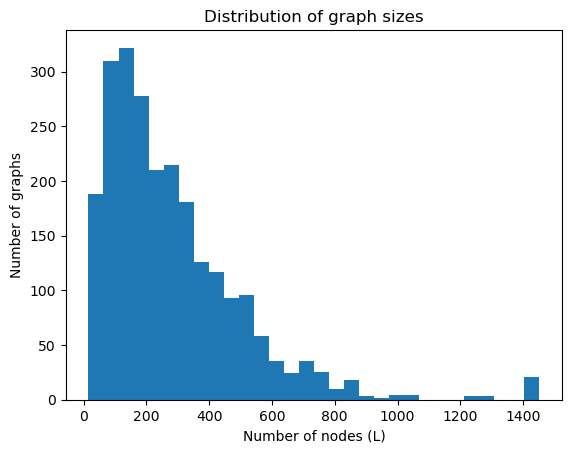

Biggest graph index: 959
Max edges: 2106852
Nodes: 1452


In [10]:
#distribution of the PDB in function of their lenght
all_data = torch.load("all_data_likeDCA_C_alpha.pt",weights_only=False)   
import matplotlib.pyplot as plt

lengths = [data.num_nodes for data in all_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

max_edges = 0
max_idx = -1

for i, data in enumerate(all_data):
    n_edges = data.edge_index.size(1)
    if n_edges > max_edges:
        max_edges = n_edges
        max_idx = i

print("Biggest graph index:", max_idx)
print("Max edges:", max_edges)
print("Nodes:", all_data[max_idx].num_nodes)

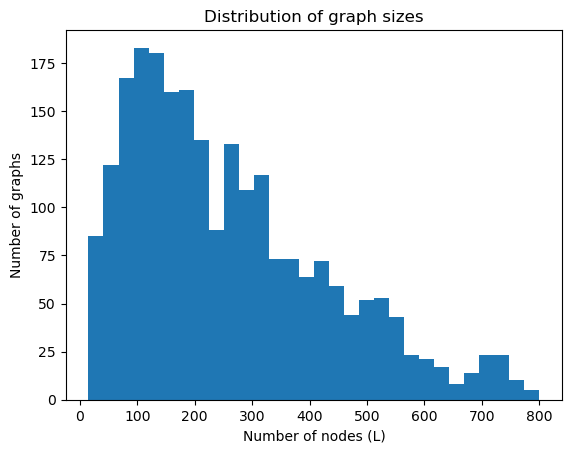

In [11]:
#biggest PDB are removed for memory cost
MAX_NODES = 800

filtered_data = [data for data in all_data if data.num_nodes <= MAX_NODES]

lengths = [data.num_nodes for data in filtered_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

In [12]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(filtered_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [13]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [14]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [15]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [16]:
#function to compute the loss in the validation step, this approach is removed in future version of training
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, hidden_ch=25, mlp_hidden_ch=12, GNN_layers=3).to(device)

save_path = "best_model_cc_likeDCA_C_alpha.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=20,min_lr=1e-6)


train_losses = []
val_losses = []


best_val_loss = float('inf')
patience = 50
epochs_no_improve = 0

for epoch in range(3000):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

pos_weight: 7.663322448730469
Epoch 0: Train Loss=0.9214, Val Loss=0.8343
Epoch 1: Train Loss=0.8565, Val Loss=0.8247
Epoch 2: Train Loss=0.8519, Val Loss=0.8268
Epoch 3: Train Loss=0.8444, Val Loss=0.8087
Epoch 4: Train Loss=0.8261, Val Loss=0.7825
Epoch 5: Train Loss=0.8063, Val Loss=0.7842
Epoch 6: Train Loss=0.8059, Val Loss=0.7851
Epoch 7: Train Loss=0.8033, Val Loss=0.7832
Epoch 8: Train Loss=0.7995, Val Loss=0.7728
Epoch 9: Train Loss=0.8047, Val Loss=0.7756
Epoch 10: Train Loss=0.7990, Val Loss=0.7950
Epoch 11: Train Loss=0.7969, Val Loss=0.7739
Epoch 12: Train Loss=0.7983, Val Loss=0.7678
Epoch 13: Train Loss=0.7947, Val Loss=0.7870
Epoch 14: Train Loss=0.7931, Val Loss=0.7614
Epoch 15: Train Loss=0.7891, Val Loss=0.7583
Epoch 16: Train Loss=0.7897, Val Loss=0.7579
Epoch 17: Train Loss=0.7843, Val Loss=0.7719
Epoch 18: Train Loss=0.7893, Val Loss=0.7490
Epoch 19: Train Loss=0.7816, Val Loss=0.7504
Epoch 20: Train Loss=0.7788, Val Loss=0.8196
Epoch 21: Train Loss=0.7822, Val Lo

KeyboardInterrupt: 

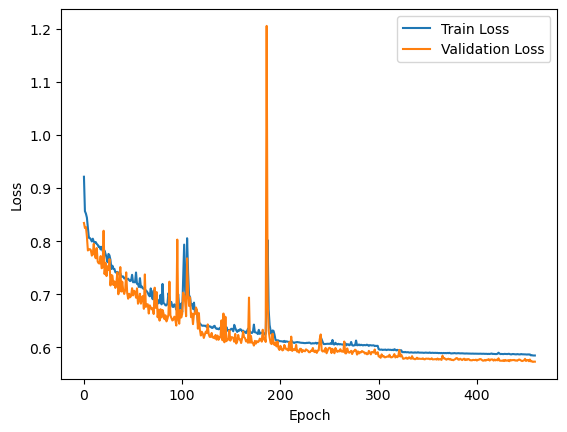

In [17]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, hidden_ch=25, mlp_hidden_ch=12, GNN_layers=3).to(device)

save_path = "best_model_cc_likeDCA_C_alpha.pt"
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

Precision of the GNN: 0.8107213258788941
Recall of the GNN: 0.43509291325127664
F1 of the GNN: 0.5662788117719197
AUPRC of the GNN: 0.7150078668898322
Validation ROC AUC GNN: 0.9326592573769528


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


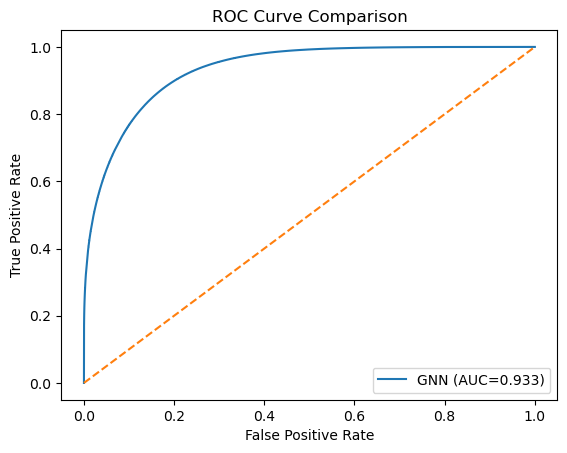

PR AUC GNN: 0.7152196498094816


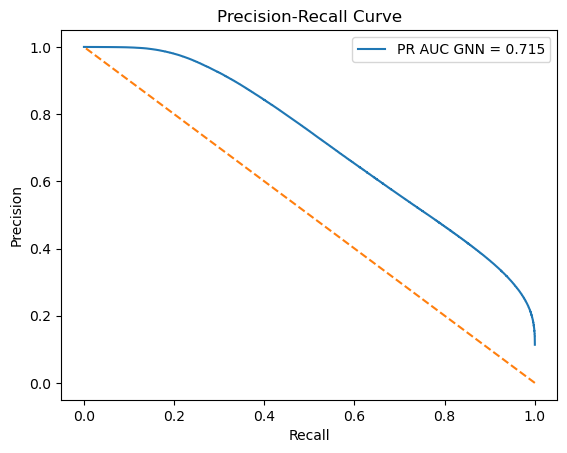

In [16]:
#ROC and Precision-Recall curve

from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


threshold=0.9

pred_contacts = (all_probs >= threshold).int().numpy()
true_contacts = all_true.int().numpy()

precision = precision_score(true_contacts, pred_contacts, zero_division=0)
recall = recall_score(true_contacts, pred_contacts, zero_division=0)
f1 = f1_score(true_contacts, pred_contacts, zero_division=0)
auprc = average_precision_score(true_contacts, all_probs.numpy())

print(f"Precision of the GNN: {np.mean(precision)}")
print(f"Recall of the GNN: {np.mean(recall)}")
print(f"F1 of the GNN: {np.mean(f1)}")
print(f"AUPRC of the GNN: {np.mean(auprc)}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [18]:
#how to evaluate the precision of the top kL contact for each graph
def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=5)[0])

Top-k*L precision: 0.9743226180816519


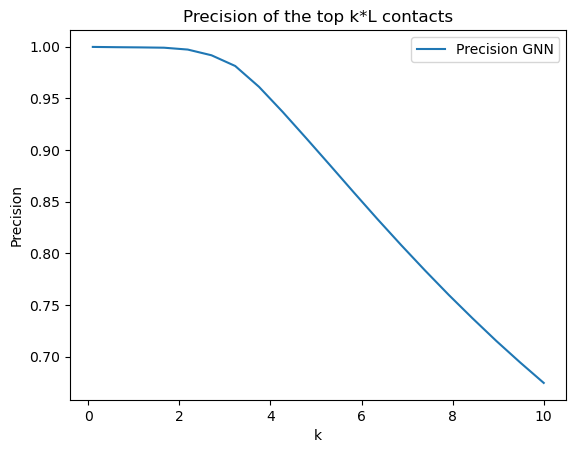

In [ ]:
#precision in function of the number of contact to predict

total_k=np.linspace(0.1,10,20)
p_GNN=[]

for k in total_k:
    prec=[]

    for batch in test_loader:
        batch = batch.to(device)

        #accuracy for a single batch
        with torch.no_grad():
            _, pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
            

        mask = batch.edge_mask & batch.pair_mask
        scores = scores[mask]

        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices


        topk_true = true_contacts[topk_idx]


        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)


    p_GNN.append(np.mean(prec))

plt.figure()

plt.plot(total_k, p_GNN, label=f"Precision GNN")


plt.xlabel("k")
plt.ylabel("Precision")
plt.title("Precision of the top k*L contacts")
plt.legend()

plt.show()

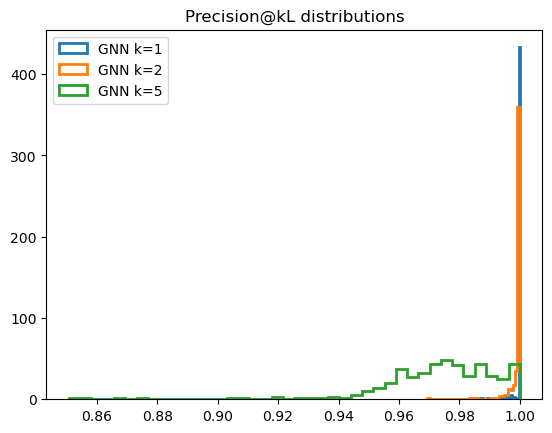

In [18]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, histtype='step',linewidth=2, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [19]:
k=5
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(max(precision))
print(precision.index(max(precision)))

[0.9677311182022095, 0.979561984539032, 0.9575308561325073, 0.9804511666297913, 0.9739299416542053, 0.9884615540504456, 0.95243901014328, 0.9863014221191406, 0.9650273323059082, 0.9931034445762634, 0.9752747416496277, 0.9800000190734863, 0.9911894798278809, 0.9676420092582703, 0.9810945987701416, 0.976344108581543, 0.9551569223403931, 0.973040759563446, 0.978317141532898, 0.9895522594451904, 0.9699999690055847, 0.9830508232116699, 0.9851852059364319, 0.9873874187469482, 0.8507500290870667, 0.9942857027053833, 0.9567567706108093, 0.9769230484962463, 1.0, 0.9463291168212891, 0.9680911302566528, 0.9563106894493103, 0.9877192974090576, 0.9811764359474182, 0.9824000000953674, 0.9591647386550903, 0.9752808809280396, 1.0, 0.9944444298744202, 0.9801169633865356, 0.9618181586265564, 0.9733332991600037, 0.9696969985961914, 1.0, 0.9616557955741882, 0.9443609118461609, 0.9651063680648804, 0.9486111402511597, 0.9886524677276611, 0.9862745404243469, 0.9701389074325562, 0.99294114112854, 1.0, 0.98181

In [20]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Data(x=[227, 16], edge_index=[2, 51302], edge_attr=[51302, 1], y=[51302, 1], edge_mask=[51302], pair_mask=[51302], L=227)


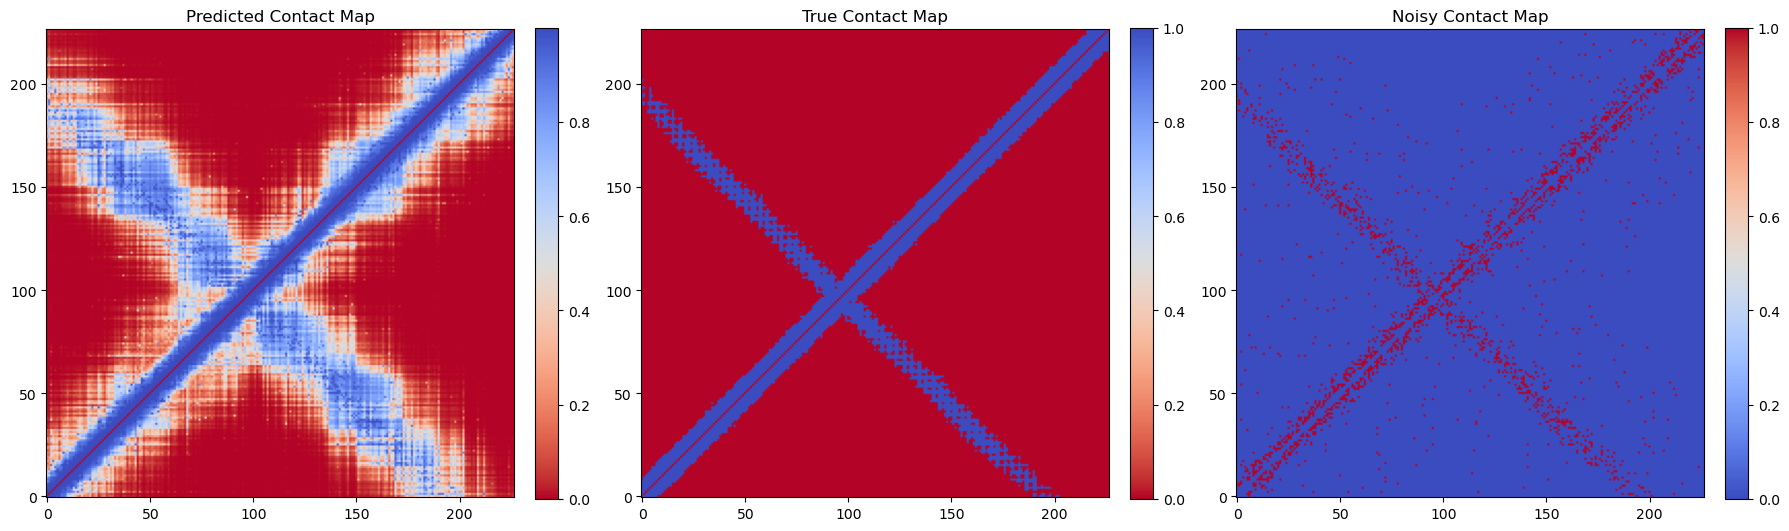

In [21]:
    
pos=12
#best case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)



scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.8
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [21]:
#test on DCA data

folder_path = "Data_C_alpha"

dca_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']

        #each DCA score is transformed into a contact map with 5L contacts
        k = 5*len(sequence)  
        binary_map = top_k_mask(contact_map_DCA, k)
        
        data = build_graph_contact(binary_map, distance_map)
        
        dca_data.append(data)

test_dca_loader = DataLoader(dca_data, batch_size=1, shuffle=False)

Validation ROC AUC GNN: 0.869543816150051
Validation ROC AUC GNN: 0.7264410605683164


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


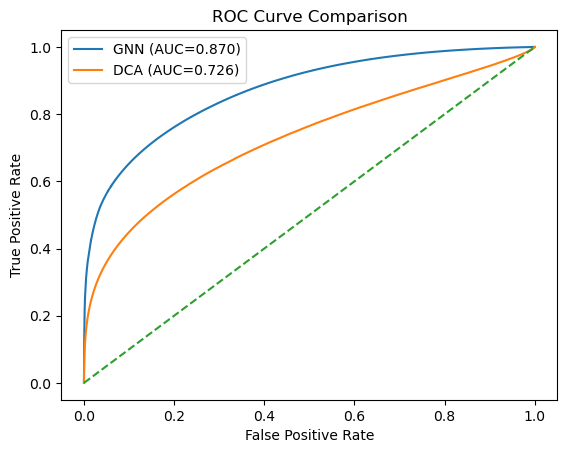

PR AUC GNN: 0.606905935576566
PR AUC DCA: 0.39223328213345915


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


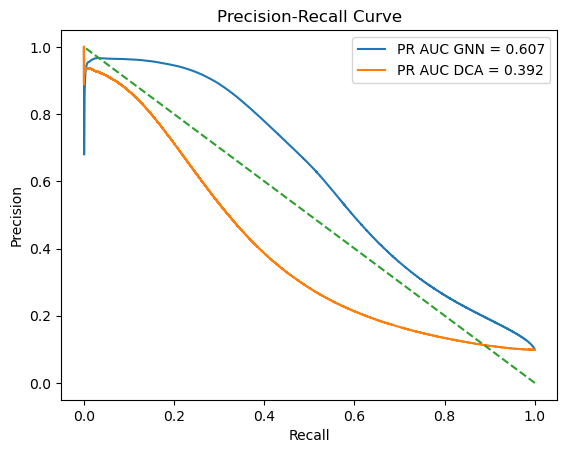

In [23]:
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

#DCA scores
all_scores = []
all_labels = []

min_sep=0

folder_path="Data_C_alpha"
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=11.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten
        scores = contact_map_DCA[mask].flatten()
        labels = true_contact_map[mask].flatten()

        all_scores.append(scores)
        all_labels.append(labels)

all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)


#Model scores
model.eval()

all_probs = []
all_true = []

for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)


print("Validation ROC AUC GNN:", roc_auc)


fpr_dca, tpr_dca, _ = roc_curve(all_labels, all_scores)
roc_auc_dca = auc(fpr_dca, tpr_dca)


print("Validation ROC AUC GNN:", roc_auc_dca)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot(fpr_dca, tpr_dca, label=f"DCA (AUC={roc_auc_dca:.3f})")


plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)



precision_dca, recall_dca, _ = precision_recall_curve(all_labels, all_scores)
pr_auc_dca = auc(recall_dca, precision_dca)


print("PR AUC DCA:", pr_auc_dca)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot(recall_dca, precision_dca, label=f"PR AUC DCA = {pr_auc_dca:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [27]:
#precision for the GNN and DCA


#GNN precision
k=2

prec=[]

for batch in test_dca_loader:
    batch = batch.to(device)

    #accuracy for a single batch
    with torch.no_grad():
        _, pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
    
    upper_mask = batch.edge_index[0] < batch.edge_index[1]
    mask = batch.edge_mask & batch.pair_mask & upper_mask
    scores = scores[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    L = batch.L
    topk = int(k * L)

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

    topk_true = true_contacts[topk_idx]

    num_correct = topk_true.sum()
    precision = (num_correct / len(topk_true)).item()
    prec.append(precision)
print(np.mean(prec))


#DCA precision
prec_dca=[]
min_sep=0

folder_path="Data_C_alpha"
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=11.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten and go to torch
        scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
        labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = labels[topk_idx]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec_dca.append(precision)
print(np.mean(prec_dca))



0.9658076710569171
0.7371222509310031


In [26]:
#for the GNN it's possible to obtain the same with the function topk_L_precision
k=5

print("Top-k*L precision GNN:", topk_L_precision(model, test_dca_loader, device, ratio=k)[0])


Top-k*L precision GNN: 0.7895759449937405


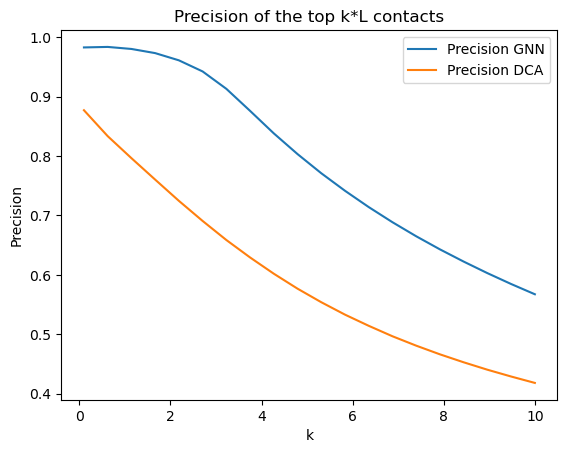

In [28]:
#precision in function of the number of contact to predict
total_k=np.linspace(0.1,10,20)
p_GNN=[]
p_DCA=[]
for k in total_k:

    #GNN    
    prec=[]

    for batch in test_dca_loader:
        batch = batch.to(device)
        
        #accuracy for a single batch
        with torch.no_grad():
            _, pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
        
        upper_mask = batch.edge_index[0] < batch.edge_index[1]
        mask = batch.edge_mask & batch.pair_mask & upper_mask
        scores = scores[mask]
        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = true_contacts[topk_idx]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)
    
    p_GNN.append(np.mean(prec))

    #DCA

    prec_dca=[]


    min_sep=0

    folder_path="Data_C_alpha"
    for file in os.listdir(folder_path):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                loaded = pickle.load(f)

            sequence = loaded['sequence']
            distance_map = loaded['distance_map']
            contact_map_DCA = loaded['dca']

            true_contact_map = contact_from_distance(distance_map, threshold=11.0)
            
            L = len(sequence)
            i, j = np.indices((L, L))

            mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
            # Flatten and go to torch
            scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
            labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

            topk = int(k * L)

            topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

            topk_true = labels[topk_idx]

            num_correct = topk_true.sum()
            precision = (num_correct / len(topk_true)).item()
            prec_dca.append(precision)

    p_DCA.append(np.mean(prec_dca))
    

plt.figure()

plt.plot(total_k, p_GNN, label=f"Precision GNN")
plt.plot(total_k, p_DCA, label=f"Precision DCA")


plt.xlabel("k")
plt.ylabel("Precision")
plt.title("Precision of the top k*L contacts")
plt.legend()

plt.show()

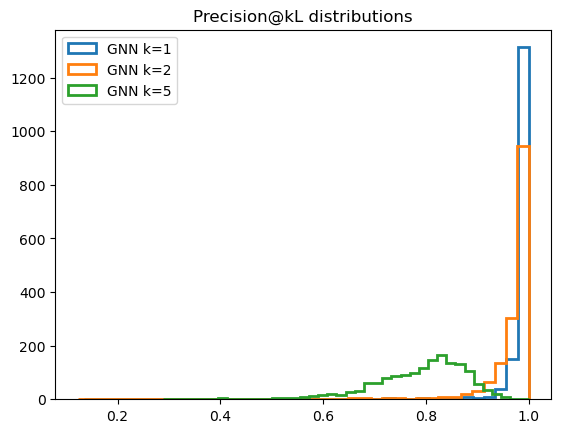

In [29]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, histtype='step',linewidth=2, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [30]:
k=1
precision= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))
print(max(precision))
print(precision.index(max(precision)))

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9876543283462524, 1.0, 0.9639639854431152, 1.0, 1.0, 0.9523810148239136, 0.9803922176361084, 0.9582637548446655, 0.9853658676147461, 1.0, 1.0, 0.9809523820877075, 0.9999999403953552, 0.9545454978942871, 1.0, 1.0, 1.0, 0.9694656729698181, 0.9999999403953552, 0.9724137783050537, 0.8137754797935486, 0.9999999403953552, 1.0, 0.9999999403953552, 0.9858155846595764, 1.0, 0.9972973465919495, 0.9924812316894531, 1.0, 1.0, 0.9842105507850647, 0.9860464930534363, 1.0, 1.0, 0.9908256530761719, 0.9836400747299194, 0.9854651093482971, 1.0, 0.9734299182891846, 0.9650485515594482, 1.0, 0.9915611147880554, 1.0, 1.0, 0.936170220375061, 0.9382716417312622, 0.9899749159812927, 0.9772727489471436, 0.927480936050415, 0.9683544635772705, 1.0, 0.9847715497016907, 0.9815303683280945, 1.0, 1.0, 0.9569892287254333, 1.0, 0.976331353187561, 0.9971264600753784, 0.9956896305084229, 1.0, 0.9579832553863525, 0.9867549538612366, 0.9960784912109375, 1.0, 1.0, 1.0, 0.9973890781

Data(x=[65, 16], edge_index=[2, 4160], edge_attr=[4160, 1], y=[4160, 1], edge_mask=[4160], pair_mask=[4160], L=65)


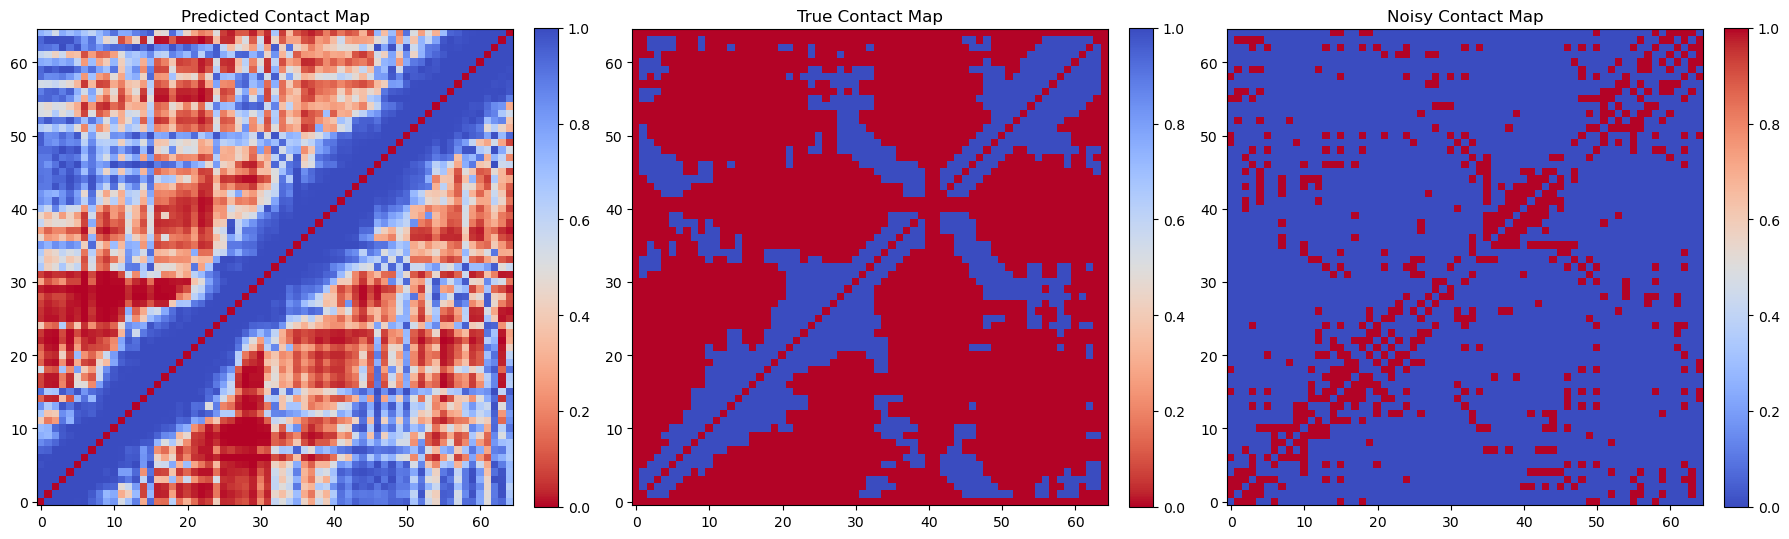

In [31]:
pos=0


i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.9
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Data(x=[104, 16], edge_index=[2, 10712], edge_attr=[10712, 1], y=[10712, 1], edge_mask=[10712], pair_mask=[10712], L=104)


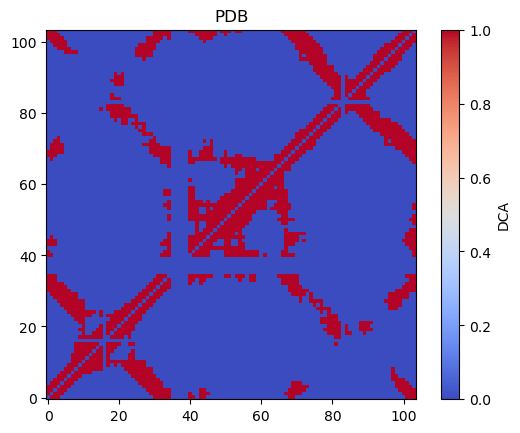

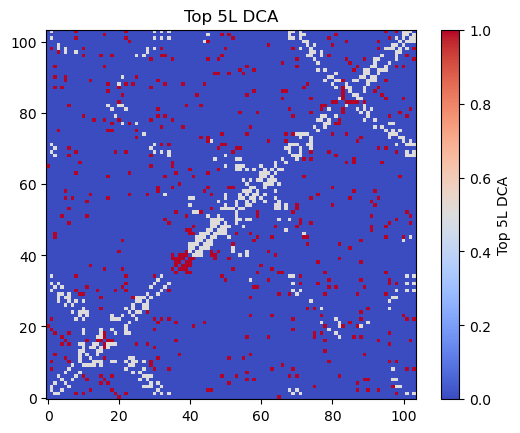

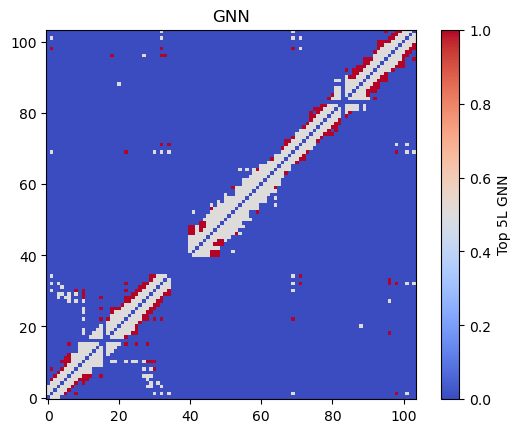

TP: 402, FP: 118, Precision GNN @ 5: 0.7731


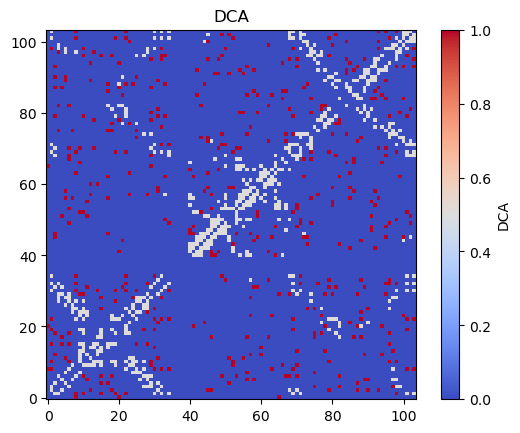

TP: 292, FP: 228, Precision DCA @5: 0.5615


In [32]:
pos=3

#changing k it's possible to visualize the top kL prediction and to see if they are good or not
k=5


i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask
mask_matrix = graph_to_matrix(batch, mask.squeeze(-1).cpu().float())

L= batch.L

scores = torch.sigmoid(pred_logits.squeeze(-1))
pred_contact_map = graph_to_matrix(batch, scores.cpu())


new_map = top_k_mask(pred_contact_map, int(k* L), mask=mask_matrix).astype(np.float32)
contact_map = graph_to_matrix(batch, batch.y.cpu()).numpy()
noisy_contact_map = graph_to_matrix(batch, batch.edge_attr.cpu()).numpy()



#original pdb
plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("PDB")
plt.show()


#top 5L dca (as in the training)
true_positives = (noisy_contact_map == 1) & (contact_map == 1)
false_positives = (noisy_contact_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1:# and mask_matrix[i][j] == 1   :
            result[i][j] = 0.5
        elif false_positives[i][j] == 1:# and mask_matrix[i][j]  == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="Top 5L DCA")
plt.title("Top 5L DCA")
plt.show()


#graph predicted from GNN (top kL)
true_positives = (new_map == 1) & (contact_map == 1)
false_positives = (new_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] and mask_matrix[i][j] == 1:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and mask_matrix[i][j] == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="Top 5L GNN")
plt.title("GNN")
plt.show()






# precision of GNN

edge_mask = (batch.edge_mask & batch.pair_mask)

scores_flat = scores[edge_mask]
true_flat = batch.y.squeeze(-1)[edge_mask]

kappa = int(k * L)
kappa = min(kappa, scores_flat.numel())

topk_idx = torch.topk(scores_flat, k=kappa).indices.cpu()
topk_true = true_flat[topk_idx]

precision = topk_true.float().mean().item()
tp = (topk_true > 0.5).sum().item()
fp = kappa - tp

print(f"TP: {tp}, FP: {fp}, Precision GNN @ {k}: {precision:.4f}")



##graph predicted from DCA (top kL)


i=0
folder_path="Data_C_alpha"
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)
        if i==pos:
            sequence = loaded['sequence']
            distance_map = loaded['distance_map']
            contact_map_DCA = loaded['dca']
            break
        i+=1

true_contact_map = contact_from_distance(distance_map, threshold=11.0)
            
L = len(sequence)
i, j = np.indices((L, L))

mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
# Flatten and go to torch
scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

topk = int(k * L)

topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices
# build full L×L map
new_map = np.zeros(mask.shape, dtype=np.float32)

flat_indices = np.flatnonzero(mask)  # positions in original matrix

selected_positions = flat_indices[topk_idx.cpu().numpy()]

# convert flat indices back to 2D
rows, cols = np.unravel_index(selected_positions, mask.shape)

new_map[rows, cols] = 1.0
new_map[cols, rows] = 1.0  # if symmetric contacts


true_positives = (new_map == 1) & (contact_map == 1)
false_positives = (new_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] and mask_matrix[i][j] == 1:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and mask_matrix[i][j] == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA")
plt.show()



#precision DCA
topk_true = labels[topk_idx]

precision = topk_true.float().mean().item()
tp = (topk_true > 0.5).sum().item()
fp = kappa - tp

print(f"TP: {tp}, FP: {fp}, Precision DCA @{k}: {precision:.4f}")


In [35]:
#we want to see if the prediction for not near-diagonal terms have been improved or not
min_sep = 5
k = 0.5



prec = []

for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
        
    # keep only valid pairs and exclude diagonal / near-diagonal pairs
    sep_mask = (batch.edge_index[0] - batch.edge_index[1]).abs() >= min_sep
    upper_mask = batch.edge_index[0] < batch.edge_index[1]
    mask = batch.edge_mask & batch.pair_mask & sep_mask & upper_mask

    scores = scores[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    L = batch.L
    topk = int(k * L)

    if scores.numel() == 0:
        continue

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

    topk_true = true_contacts[topk_idx]


    precision = topk_true.float().mean().item() if len(topk_true) > 0 else 0.0


    prec.append(precision)

print(f"Precision of the GNN: {np.mean(prec)}")



prec=[]
folder_path="Data_C_alpha"
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=11.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten
        scores = torch.tensor(contact_map_DCA[mask].flatten())
        labels = torch.tensor(true_contact_map[mask].flatten())

        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = labels[topk_idx]

        precision = topk_true.float().mean().item() if len(topk_true) > 0 else 0.0

        prec.append(precision)



print(f"Precision of the DCA: {np.mean(prec)}")

Precision of the GNN: 0.5816428476049064
Precision of the DCA: 0.6959951122685407


In [ ]:
min_sep = 5
threshold = 0.5

accs = []

for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))

    # keep only valid pairs and exclude near-diagonal pairs
    sep_mask = (batch.edge_index[0] - batch.edge_index[1]).abs() >= min_sep
    upper_mask = batch.edge_index[0] < batch.edge_index[1]
    mask = batch.edge_mask & batch.pair_mask & sep_mask & upper_mask

    scores = scores[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    if scores.numel() == 0:
        continue

    # binary predictions
    preds = (scores >= threshold).float()

    # accuracy
    accuracy = (preds == true_contacts).float().mean().item()

    accs.append(accuracy)

print(f"Accuracy of the GNN: {np.mean(accs):.4f}")


accs = []
folder_path = "Data_C_alpha"

for file in os.listdir(folder_path):
    if file.endswith(".pkl"):

        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=11.0)

        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (
            np.isfinite(distance_map)
            & (np.abs(i - j) >= min_sep)
            & (i < j)
        )

        scores = torch.tensor(contact_map_DCA[mask].flatten())
        labels = torch.tensor(true_contact_map[mask].flatten())

        if scores.numel() == 0:
            continue

        # binary predictions
        preds = (scores >= threshold).float()

        # accuracy
        accuracy = (preds == labels).float().mean().item()

        accs.append(accuracy)

print(f"Accuracy of the DCA: {np.mean(accs):.4f}")

Accuracy of the GNN: 0.6573
Accuracy of the DCA: 0.8727
